#Process Data

##Import Packages

In [ ]:
!pip install keras_cv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.9/601.9 kB 12.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 67.9 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import scipy as sp
import pandas as pd
import seaborn as sns
from PIL import Image
import tensorflow as tf
import keras_cv
from tensorflow.data import AUTOTUNE
import tensorflow.keras as keras
import matplotlib.pyplot as plt
from tensorflow.keras.layers import (
    RandomBrightness, RandomZoom, RandomFlip,
    Input, Conv2D, BatchNormalization, MaxPool2D, Dropout, Flatten, Dense
)

Using TensorFlow backend


## Load Data

In [ ]:
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
image_size = (150,150)

train_data = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Alzheimer_s Dataset/train',
    color_mode = 'grayscale',
    class_names = class_names,
    image_size = image_size,
    label_mode = 'categorical',
    batch_size = 10000
)

val_data = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Alzheimer_s Dataset/test',
    color_mode = 'grayscale',
    class_names = class_names,
    image_size = image_size,
    label_mode = 'categorical',
    batch_size = 10000
)

##Convert to Numpy Arrays

In [ ]:
X_train, y_train = train_data.as_numpy_iterator().next()
X_val, y_val = val_data.as_numpy_iterator().next()

del train_data
del val_data

X = np.concatenate([X_train,X_val],axis=0)
y = np.concatenate([y_train,y_val],axis=0)

## View Class Imblance

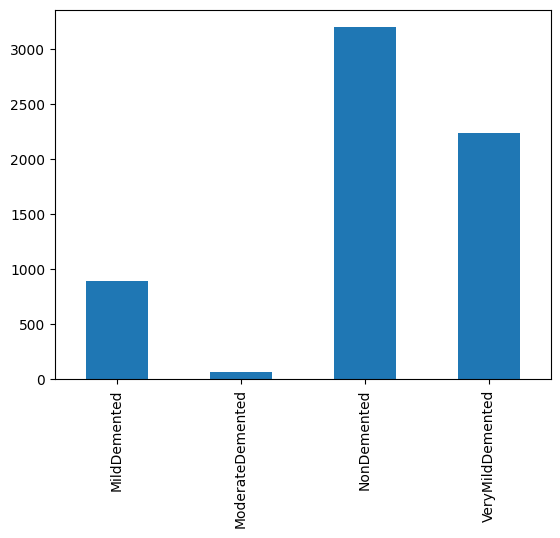

In [ ]:
def plot_imbalance(y):
    class_totals = pd.Series([0,0,0,0], index = class_names)
    y_sparse = np.argmax(y, axis = -1)
    for i,class_name in enumerate(class_names):
        total = np.sum(y_sparse == i)
        class_totals[class_name] = total
    class_totals.plot.bar()

plot_imbalance(y)

## View Data

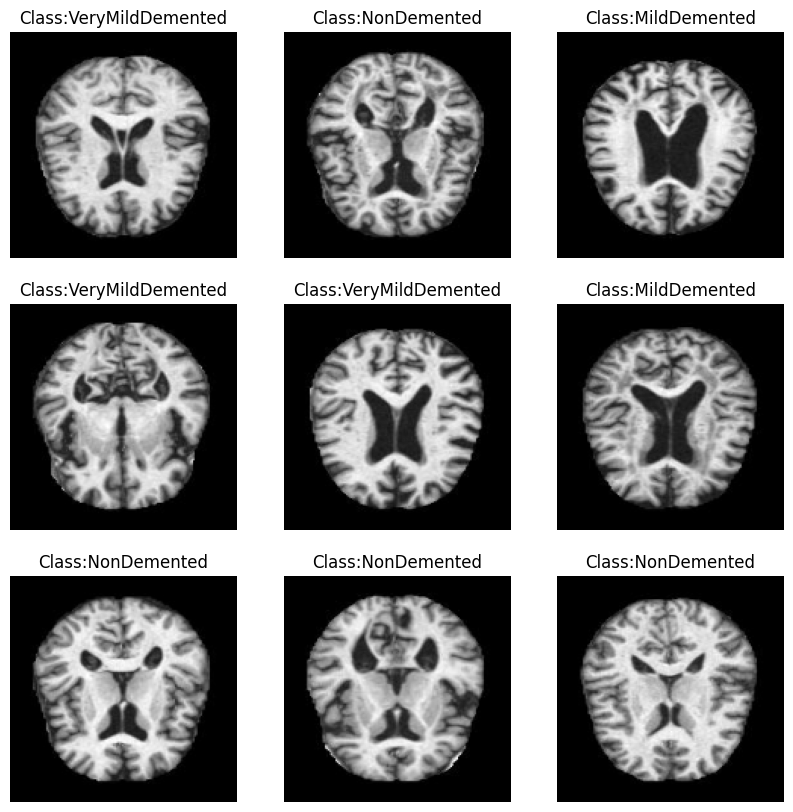

In [ ]:
def show_images(X,y, random = True):
    """
    Input: An image list
    Output: Displays a grid of 9 images with lables
    """

    # get image lables
    labels =dict(zip([0,1,2,3], class_names))

    # get a batch of images
    # display a grid of 9 images
    plt.figure(figsize=(10, 10))
    for i in range(9):
        if random:
            idx = np.random.randint(0,y.shape[0])
        else:
            idx = i
        x = X[idx]
        label = y[idx]
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(x, cmap = 'gray')
        plt.axis("off")
        plt.title("Class:{}".format(labels[np.argmax(label)]))

# Display Train Images
show_images(X,y)

## Plot Brightness

Some of the examples look abnormally dark.

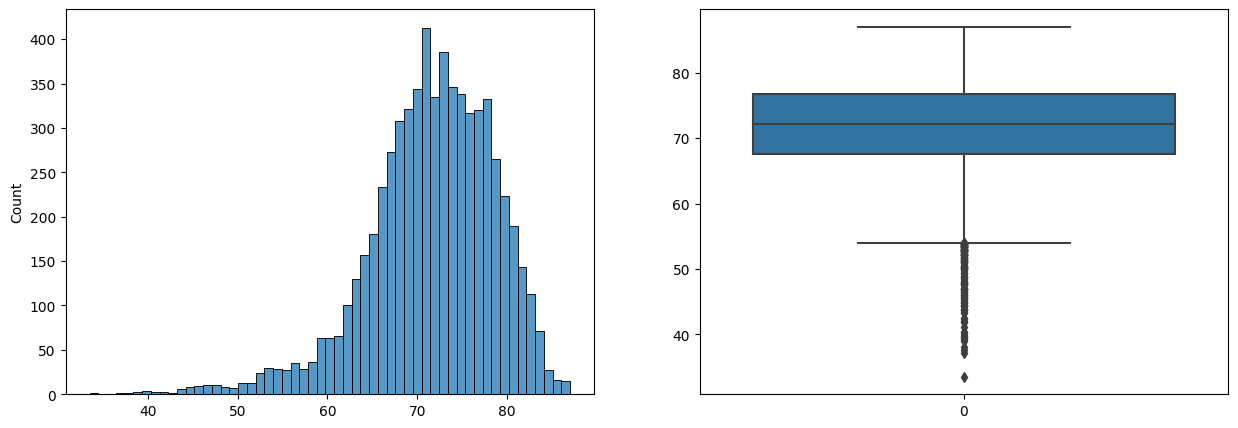

In [ ]:
def plot_brightness(X,y):
    brightness = []

    for image, label in zip(X,y):
        brightness.append(np.mean(image))

    plt.figure(figsize = (15,5))
    plt.subplot(1,2,1)
    sns.histplot(brightness)
    plt.subplot(1,2,2)
    sns.boxplot(brightness)

plot_brightness(X,y)

## View Outlaiers

lower fence: 53.980408668518066
number of outliers: 159


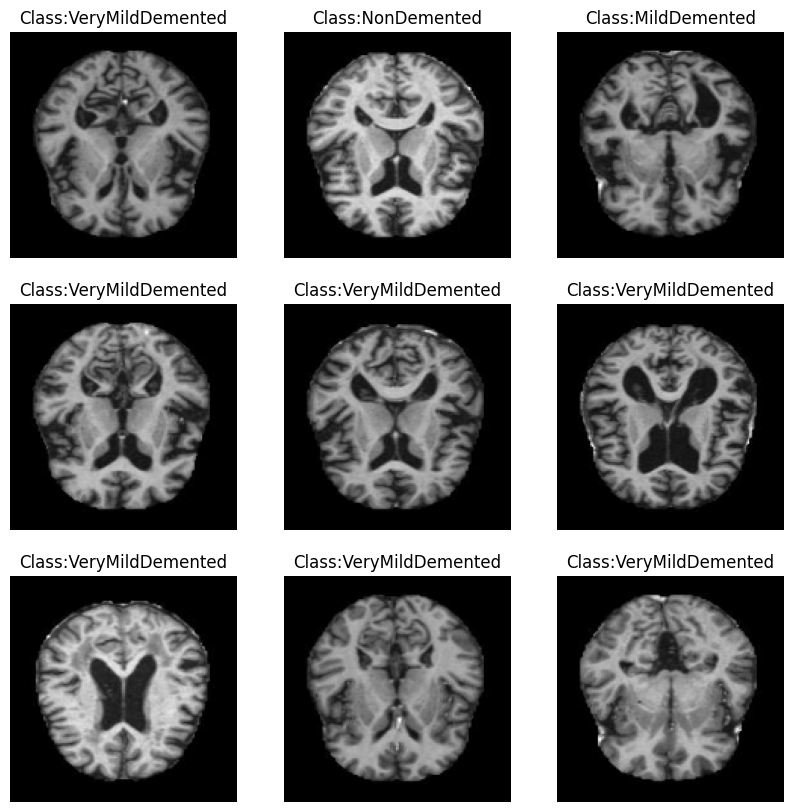

In [ ]:
def show_outliers(X,y):
    brightness = []

    for image, label in zip(X,y):
        brightness.append(np.mean(image))

    q1 = np.quantile(brightness,.25)
    iqr = np.subtract(*np.percentile(brightness, [75, 25]))
    lower_fence = q1 - 1.5*iqr
    print('lower fence:',lower_fence)

    X_out = []
    y_out = []
    for x,label in zip(X,y):
        if np.mean(x) < lower_fence:
            X_out.append(x)
            y_out.append(label)

    print('number of outliers:', len(y_out))
    show_images(X_out,y_out, False)

show_outliers(X,y)

## Reassign outlaier brightness

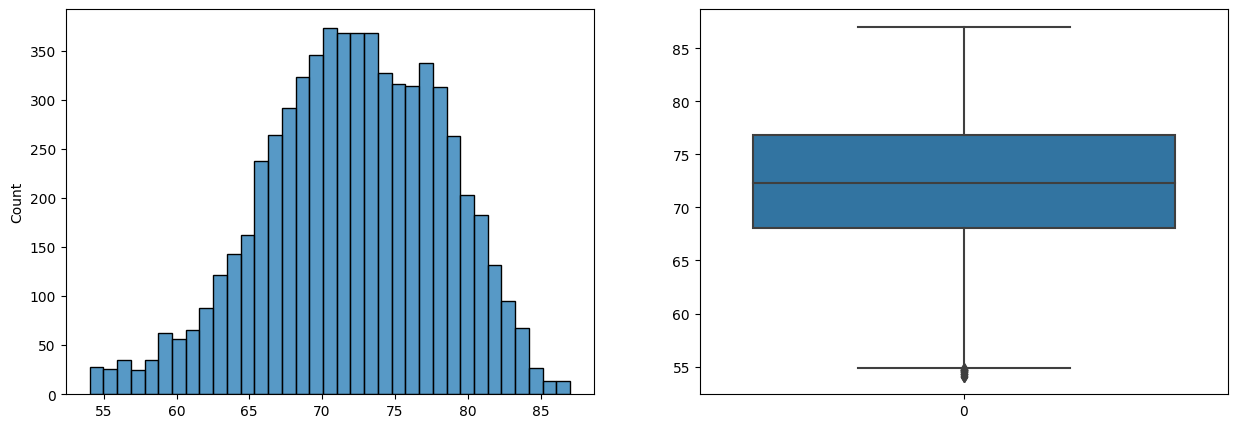

In [ ]:
def unskew_brightness(X):

    brightness = []

    for image in X:
        brightness.append(np.mean(image))

    mew = np.median(brightness)
    q1 = np.quantile(brightness,.25)
    iqr = np.subtract(*np.percentile(brightness, [75, 25]))
    lower_fence = q1 - 1.5*iqr
    sigma = iqr/1.35

    unskewed = np.zeros(X.shape)

    for i,image in enumerate(X):

        if brightness[i] < lower_fence:
            new_image = sigma*np.clip(np.random.randn(1),-1,1)+mew*(image/brightness[i])
        else:
            new_image = image
        unskewed[i] = new_image

    return unskewed


X = unskew_brightness(X)
plot_brightness(X,y)

Most of the darkened images were removed put some brighter outliers blend in with the brightness of normal images so not all are accounted for.

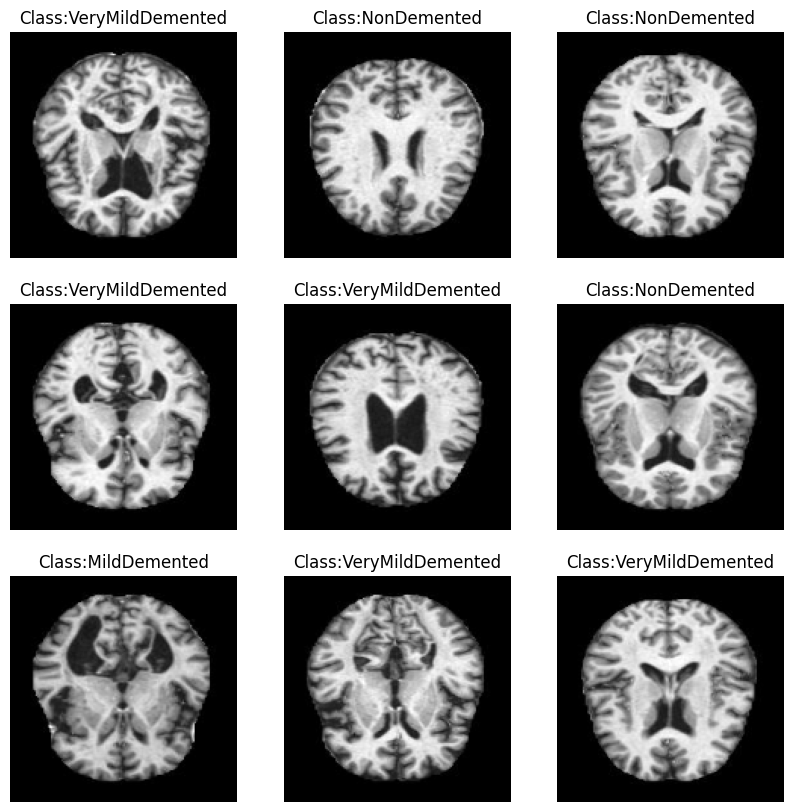

In [ ]:
show_images(X,y)

In [ ]:
def save_as_npy(X, y):
    # Save X (processed images) into X_final.npy file
    np.save('X_final.npy', X)

    # Save y (labels) into Y_final.npy file
    np.save('Y_final.npy', y)
save_as_npy(X, y)

## Load The processed images and labels

In [ ]:
X_loaded = np.load('/content/drive/MyDrive/Alzheimer Dataset preprocessed/X_final.npy')
Y_loaded = np.load('/content/drive/MyDrive/Alzheimer Dataset preprocessed/Y_final.npy')

##Split the data into training and validation sets

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_loaded, Y_loaded, test_size=0.2, random_state=42)